Suggested environment: [gds_env](https://darribas.org/gds_env/) (use Python version)

# 2021 UK Census data prep

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from functools import reduce

from sodaprep import *

In [2]:
# Configure logging
import warnings
import logging

def _simple_warning_format(message, category, filename, lineno, file=None, line=None):
    logging.warning(f'{category.__name__}: {message}')
logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')
warnings.showwarning = _simple_warning_format
warnings.simplefilter('always')

## Load data

### Load topic tables

In [3]:
# Locate all parquet files in the topic_tables folder and sort by filename
parquet_dir   = Path('data/processed/28714514/output_data_set/topic_tables/parquet')
parquet_files = sorted(parquet_dir.glob('*.parquet'), key=lambda p: p.name)
parquet_files

[PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk001.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk002.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk003.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk004.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk007a.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk008.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk015.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk017.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk021.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk023.parquet'),
 PosixPath('data/processed/28714514/output_data_set/topic_tables/parquet/uk029.parquet'),
 PosixPat

In [4]:
# Read each into a dataframe
dfs = [pd.read_parquet(fp) for fp in parquet_files]

In [5]:
# Inner-join them all on the 'OA' column
df = reduce(lambda left, right: left.join(right, how='inner'), dfs)
df.shape

(239023, 215)

In [6]:
df.head()

,uk001001,uk001002,uk001003,uk002001,uk002002,uk002003,uk002004,uk002005,uk002006,uk003001,...,uk066016,uk066017,uk066018,uk066019,uk067001,uk067002,uk067003,uk067004,uk067005,uk067006
OA,,,,,,,,,,,,,,,,,,,,,
E00000001,176,176,0,163,34,97,9,14,9,94,...,5,2,1,3,155,4,17,1,11,122
E00000003,256,256,0,217,67,130,1,9,10,109,...,19,6,0,1,221,5,11,1,20,184
E00000005,112,112,0,106,43,42,4,10,7,63,...,3,3,1,6,106,3,5,3,7,88
E00000007,144,144,0,139,99,29,2,4,5,86,...,11,1,1,2,137,5,7,1,7,117
E00000010,178,178,0,171,132,29,1,8,1,128,...,8,0,9,9,164,15,33,0,23,93


### Load information for normalisation

In [7]:
vars_totals_full = pd.read_excel('data/53626316_Variable_Totals_atlevel.xlsx', engine='openpyxl')
vars_totals_full.head()

,Variable_ID,Variable_Name,Table_ID,Table_Name,Unit,Total_ID,Total_Name,Total_Table_ID,Redundant
0,uk001001,Residence type: Total,uk001,Residence type,Person,NaN,NaN,NaN,1.0
1,uk001002,Residence type: Lives in a household,uk001,Residence type,Person,uk001001,Residence type: Total,uk001,NaN
2,uk001003,Residence type: Lives in a communal establishment,uk001,Residence type,Person,uk001001,Residence type: Total,uk001,1.0
3,uk002001,Marital and civil partnership status: Total,uk002,Marital and civil partnership status,Person,NaN,NaN,NaN,1.0
4,uk002002,Marital and civil partnership status: Never ma...,uk002,Marital and civil partnership status,Person,uk002001,Marital and civil partnership status: Total,uk002,NaN


In [8]:
vars_info = vars_totals_full[['Variable_ID', 'Variable_Name']].copy()
vars_info.head()

,Variable_ID,Variable_Name
0,uk001001,Residence type: Total
1,uk001002,Residence type: Lives in a household
2,uk001003,Residence type: Lives in a communal establishment
3,uk002001,Marital and civil partnership status: Total
4,uk002002,Marital and civil partnership status: Never ma...


## Normalise variables by totals

In [9]:
vars_totals_df = vars_totals_full.copy()
vars_totals_df = vars_totals_df.dropna(subset=['Total_ID'])
vars_totals_df.head()

,Variable_ID,Variable_Name,Table_ID,Table_Name,Unit,Total_ID,Total_Name,Total_Table_ID,Redundant
1,uk001002,Residence type: Lives in a household,uk001,Residence type,Person,uk001001,Residence type: Total,uk001,NaN
2,uk001003,Residence type: Lives in a communal establishment,uk001,Residence type,Person,uk001001,Residence type: Total,uk001,1.0
4,uk002002,Marital and civil partnership status: Never ma...,uk002,Marital and civil partnership status,Person,uk002001,Marital and civil partnership status: Total,uk002,NaN
5,uk002003,Marital and civil partnership status: Married ...,uk002,Marital and civil partnership status,Person,uk002001,Marital and civil partnership status: Total,uk002,NaN
6,uk002004,Marital and civil partnership status: Separate...,uk002,Marital and civil partnership status,Person,uk002001,Marital and civil partnership status: Total,uk002,NaN


In [10]:
vars_totals = []
for row in vars_totals_df.iterrows():
    var_id = row[1]['Variable_ID']
    tot_id = row[1]['Total_ID']
    vars_totals.append((var_id, tot_id))
vars_totals[:5] 

[('uk001002', 'uk001001'),
 ('uk001003', 'uk001001'),
 ('uk002002', 'uk002001'),
 ('uk002003', 'uk002001'),
 ('uk002004', 'uk002001')]

In [11]:
df_ntot = get_normd_by_total(
        df, vars_totals, 
        to_percent=True, clip=True)
df_ntot.shape

(239023, 190)

In [12]:
df_ntot.head()

,uk001002_ntot,uk001003_ntot,uk002002_ntot,uk002003_ntot,uk002004_ntot,uk002005_ntot,uk002006_ntot,uk003002_ntot,uk003003_ntot,uk003004_ntot,...,uk066015_ntot,uk066016_ntot,uk066017_ntot,uk066018_ntot,uk066019_ntot,uk067002_ntot,uk067003_ntot,uk067004_ntot,uk067005_ntot,uk067006_ntot
OA,,,,,,,,,,,,,,,,,,,,,
E00000001,100.0,0.0,20.858896,59.509202,5.521472,8.588957,5.521472,36.170213,47.058824,52.941176,...,82.539683,7.936508,3.174603,1.587302,4.761905,2.580645,10.967742,0.645161,7.096774,78.709677
E00000003,100.0,0.0,30.875576,59.907834,0.460829,4.147465,4.608295,24.770642,40.740741,59.259259,...,68.674699,22.891566,7.228916,0.000000,1.204819,2.262443,4.977376,0.452489,9.049774,83.257919
E00000005,100.0,0.0,40.566038,39.622642,3.773585,9.433962,6.603774,41.269841,34.615385,65.384615,...,63.888889,8.333333,8.333333,2.777778,16.666667,2.830189,4.716981,2.830189,6.603774,83.018868
E00000007,100.0,0.0,71.223022,20.863309,1.438849,2.877698,3.597122,43.023256,8.108108,91.891892,...,53.125000,34.375000,3.125000,3.125000,6.250000,3.649635,5.109489,0.729927,5.109489,85.401460
E00000010,100.0,0.0,77.192982,16.959064,0.584795,4.678363,0.584795,75.000000,17.708333,82.291667,...,36.585366,19.512195,0.000000,21.951220,21.951220,9.146341,20.121951,0.000000,14.024390,56.707317


In [13]:
df_ntot.index

Index(['E00000001', 'E00000003', 'E00000005', 'E00000007', 'E00000010',
       'E00000013', 'E00000018', 'E00000019', 'E00000020', 'E00000021',
       ...
       'W00010688', 'W00010689', 'W00010690', 'W00010691', 'W00010692',
       'W00010693', 'W00010694', 'W00010695', 'W00010696', 'W00010697'],
      dtype='object', name='OA', length=239023)

In [14]:
df_ntot.columns

Index(['uk001002_ntot', 'uk001003_ntot', 'uk002002_ntot', 'uk002003_ntot',
       'uk002004_ntot', 'uk002005_ntot', 'uk002006_ntot', 'uk003002_ntot',
       'uk003003_ntot', 'uk003004_ntot',
       ...
       'uk066015_ntot', 'uk066016_ntot', 'uk066017_ntot', 'uk066018_ntot',
       'uk066019_ntot', 'uk067002_ntot', 'uk067003_ntot', 'uk067004_ntot',
       'uk067005_ntot', 'uk067006_ntot'],
      dtype='object', length=190)

## Clip outliers

In [15]:
df_ntot_cl10 = get_clipped_outliers(df_ntot, df_ntot.columns, method='iqr_diff', factor=10.0)
df_ntot_cl10.shape

(239023, 190)

In [16]:
df_ntot_cl10.head()

,uk001002_ntot_clipd,uk001003_ntot_clipd,uk002002_ntot_noout,uk002003_ntot_noout,uk002004_ntot_clipd,uk002005_ntot_noout,uk002006_ntot_clipd,uk003002_ntot_noout,uk003003_ntot_noout,uk003004_ntot_noout,...,uk066015_ntot_noout,uk066016_ntot_noout,uk066017_ntot_noout,uk066018_ntot_noout,uk066019_ntot_clipd,uk067002_ntot_noout,uk067003_ntot_noout,uk067004_ntot_clipd,uk067005_ntot_clipd,uk067006_ntot_noout
OA,,,,,,,,,,,,,,,,,,,,,
E00000001,100.0,0.0,20.858896,59.509202,5.521472,8.588957,5.521472,36.170213,47.058824,52.941176,...,82.539683,7.936508,3.174603,1.587302,4.761905,2.580645,10.967742,0.645161,7.096774,78.709677
E00000003,100.0,0.0,30.875576,59.907834,0.460829,4.147465,4.608295,24.770642,40.740741,59.259259,...,68.674699,22.891566,7.228916,0.000000,1.204819,2.262443,4.977376,0.452489,9.049774,83.257919
E00000005,100.0,0.0,40.566038,39.622642,3.773585,9.433962,6.603774,41.269841,34.615385,65.384615,...,63.888889,8.333333,8.333333,2.777778,16.666667,2.830189,4.716981,2.830189,6.603774,83.018868
E00000007,100.0,0.0,71.223022,20.863309,1.438849,2.877698,3.597122,43.023256,8.108108,91.891892,...,53.125000,34.375000,3.125000,3.125000,6.250000,3.649635,5.109489,0.729927,5.109489,85.401460
E00000010,100.0,0.0,77.192982,16.959064,0.584795,4.678363,0.584795,75.000000,17.708333,82.291667,...,36.585366,19.512195,0.000000,21.951220,21.951220,9.146341,20.121951,0.000000,14.024390,56.707317


## Check correlations

In [17]:
corr_dict = get_correlated_pairs(df_ntot_cl10, df_ntot_cl10.columns, threshold=0.75, method='spearman')

In [18]:
corr_df = pd.DataFrame(corr_dict)
corr_df['corr_squared'] = corr_df['correlation'] ** 2
corr_df['column_x_orig'] = corr_df['column_x_name'].str.split('_').str[0]
corr_df['column_y_orig'] = corr_df['column_y_name'].str.split('_').str[0]
corr_df = corr_df.merge(vars_info, left_on='column_x_orig', right_on='Variable_ID', how='left').rename(columns={'Variable_Name': 'column_x_info'}).drop(columns=['Variable_ID', 'column_x_orig'])
corr_df = corr_df.merge(vars_info, left_on='column_y_orig', right_on='Variable_ID', how='left').rename(columns={'Variable_Name': 'column_y_info'}).drop(columns=['Variable_ID', 'column_y_orig'])
corr_df.sort_values(by='column_x_name', inplace=True)

<Axes: >

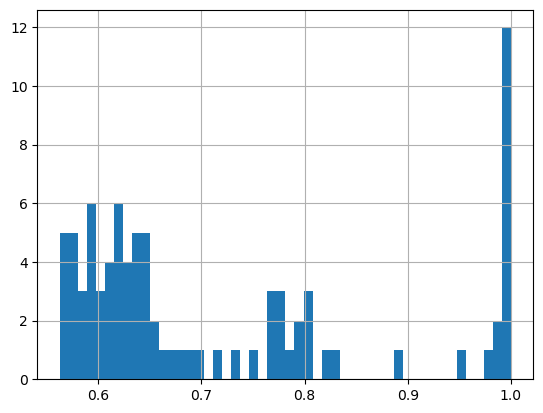

In [19]:
corr_df['corr_squared'].hist(bins=50)

In [20]:
corr100_df = corr_df.query('corr_squared == 1.0').copy()
corr100_df

,column_x_name,column_y_name,correlation,corr_squared,column_x_info,column_y_info
38,uk008002_ntot_clipd,uk008003_ntot_clipd,-1.0,1.0,Sex: Female,Sex: Male
51,uk029002_ntot_clipd,uk029003_ntot_clipd,-1.0,1.0,Proficiency in English language: Speaks Englis...,Proficiency in English language: Cannot speak ...
59,uk038002_ntot_noout,uk038005_ntot_noout,-1.0,1.0,Disability: Disabled under the Equality Act,Disability: Not disabled under the Equality Act


In [21]:
decision_corr100_drop = list(set(corr100_df['column_y_name'].values))
vars_info[vars_info['Variable_ID'].isin([col.split('_')[0] for col in decision_corr100_drop])]

,Variable_ID,Variable_Name
53,uk008003,Sex: Male
94,uk029003,Proficiency in English language: Cannot speak ...
112,uk038005,Disability: Not disabled under the Equality Act


In [22]:
df_ntot_cl10_crrd = df_ntot_cl10.copy()

In [23]:
df_ntot_cl10_crrd = df_ntot_cl10_crrd.drop(columns=decision_corr100_drop)
df_ntot_cl10_crrd.shape

(239023, 187)

In [24]:
corr085_df = corr_df.query('corr_squared > 0.85 and corr_squared < 1.0').copy()
corr085_df

,column_x_name,column_y_name,correlation,corr_squared,column_x_info,column_y_info
0,uk001002_ntot_clipd,uk001003_ntot_clipd,-1.000000,0.999999,Residence type: Lives in a household,Residence type: Lives in a communal establishment
7,uk003002_ntot_noout,uk017002_ntot_noout,0.991852,0.983770,Household composition: One person household,Household size: 1 person in household
8,uk003002_ntot_noout,uk023002_ntot_noout,0.992279,0.984619,Household composition: One person household,Multiple ethnic groups in household: One-perso...
10,uk003003_ntot_noout,uk003004_ntot_noout,-0.997230,0.994468,Household composition: One person household: A...,Household composition: One person household: O...
26,uk004003_ntot_noout,uk004004_ntot_clipd,-0.988425,0.976984,Country of birth: Europe: United Kingdom,Country of birth: Europe: EU countries
44,uk017002_ntot_noout,uk023002_ntot_noout,0.998242,0.996487,Household size: 1 person in household,Multiple ethnic groups in household: One-perso...
60,uk038003_ntot_noout,uk038004_ntot_noout,-0.999925,0.999850,Disability: Disabled under the Equality Act: D...,Disability: Disabled under the Equality Act: D...
67,uk054003_ntot_noout,uk054004_ntot_noout,-0.995745,0.991509,Tenure of household: Owned: Owns outright,Tenure of household: Owned: Owns with a mortga...
69,uk059002_ntot_noout,uk059005_ntot_noout,-0.999900,0.999799,Hours worked: Part-time,Hours worked: Full-time
70,uk059003_ntot_noout,uk059004_ntot_noout,-0.998962,0.997925,Hours worked: Part-time: 15 hours or less worked,Hours worked: Part-time: 16 to 30 hours worked


In [25]:
decision_corr085_drop = [
    'uk001003_ntot_clipd', # Residence type: Lives in a communal establishment
    'uk017002_ntot_noout', # Household size: 1 person in household
    'uk023002_ntot_noout', # Multiple ethnic groups in household: One-person household
    'uk003004_ntot_noout', # Household composition: One person household: Other
    'uk038004_ntot_noout', # Disability: Disabled under the Equality Act: Day-to-day activities limited a little
    'uk054004_ntot_noout', # Tenure of household: Owned: Owns with a mortgage, loan or shared ownership
    'uk059005_ntot_noout', # Hours worked: Full-time
    'uk059004_ntot_noout', # Hours worked: Part-time: 16 to 30 hours worked
    'uk059007_ntot_noout', # Hours worked: Full-time: 49 or more hours worked
    'uk066007_ntot_clipd', # Economic activity status: Economically active (excluding full-time students): Unemployed
]

In [26]:
corr085_df[corr085_df['column_y_name'].isin(decision_corr085_drop)]

,column_x_name,column_y_name,correlation,corr_squared,column_x_info,column_y_info
0,uk001002_ntot_clipd,uk001003_ntot_clipd,-1.000000,0.999999,Residence type: Lives in a household,Residence type: Lives in a communal establishment
7,uk003002_ntot_noout,uk017002_ntot_noout,0.991852,0.983770,Household composition: One person household,Household size: 1 person in household
8,uk003002_ntot_noout,uk023002_ntot_noout,0.992279,0.984619,Household composition: One person household,Multiple ethnic groups in household: One-perso...
10,uk003003_ntot_noout,uk003004_ntot_noout,-0.997230,0.994468,Household composition: One person household: A...,Household composition: One person household: O...
44,uk017002_ntot_noout,uk023002_ntot_noout,0.998242,0.996487,Household size: 1 person in household,Multiple ethnic groups in household: One-perso...
60,uk038003_ntot_noout,uk038004_ntot_noout,-0.999925,0.999850,Disability: Disabled under the Equality Act: D...,Disability: Disabled under the Equality Act: D...
67,uk054003_ntot_noout,uk054004_ntot_noout,-0.995745,0.991509,Tenure of household: Owned: Owns outright,Tenure of household: Owned: Owns with a mortga...
69,uk059002_ntot_noout,uk059005_ntot_noout,-0.999900,0.999799,Hours worked: Part-time,Hours worked: Full-time
70,uk059003_ntot_noout,uk059004_ntot_noout,-0.998962,0.997925,Hours worked: Part-time: 15 hours or less worked,Hours worked: Part-time: 16 to 30 hours worked
71,uk059006_ntot_noout,uk059007_ntot_noout,-0.999629,0.999259,Hours worked: Full-time: 31 to 48 hours worked,Hours worked: Full-time: 49 or more hours worked


In [27]:
corr085_df[~corr085_df['column_y_name'].isin(decision_corr085_drop)]

,column_x_name,column_y_name,correlation,corr_squared,column_x_info,column_y_info
26,uk004003_ntot_noout,uk004004_ntot_clipd,-0.988425,0.976984,Country of birth: Europe: United Kingdom,Country of birth: Europe: EU countries
83,uk066002_ntot_noout,uk066014_ntot_noout,-0.975780,0.952147,Economic activity status: Economically active ...,Economic activity status: Economically inactive
85,uk066004_ntot_noout,uk066006_ntot_clipd,-0.942274,0.887881,Economic activity status: Economically active ...,Economic activity status: Economically active ...


In [28]:
df_ntot_cl10_crrd = df_ntot_cl10_crrd.drop(columns=decision_corr085_drop)
df_ntot_cl10_crrd.shape

(239023, 177)

## IHS transformation

Check and transform variables with skewness > 3.0

In [29]:
skew_df = df_ntot_cl10_crrd.skew()
skew_df = skew_df[skew_df.abs() > 3.0]
skew_df

uk004005_ntot_clipd      3.298823
uk004008_ntot_clipd      3.235791
uk004009_ntot_clipd      3.104857
uk007a005_ntot_clipd     3.517879
uk007a006_ntot_clipd     3.968906
uk007a019_ntot_clipd     3.037976
uk015003_ntot_clipd      3.192251
uk015006_ntot_clipd      3.316153
uk015013_ntot_clipd      3.393291
uk021002_ntot_clipd      3.262115
uk021008_ntot_clipd      3.128977
uk021011_ntot_clipd      3.063371
uk023006_ntot_clipd      3.332753
uk030004_ntot_clipd      3.204847
uk030005_ntot_clipd      3.156077
uk030006_ntot_clipd      3.974675
uk044008_ntot_clipd      6.051559
uk046004_ntot_clipd      3.108578
uk046005_ntot_clipd      3.154576
uk046007_ntot_clipd      5.834870
uk046008_ntot_clipd      5.006721
uk046009_ntot_clipd      3.179208
uk046010_ntot_clipd      3.909365
uk054009_ntot_clipd      3.456162
uk061006_ntot_clipd      3.028814
uk062010_ntot_clipd      4.077884
uk066008_ntot_clipd      3.782125
uk066011_ntot_noout     11.325213
uk066012_ntot_clipd      3.170349
uk066016_ntot_

In [30]:
skew_df.index.to_list()

['uk004005_ntot_clipd',
 'uk004008_ntot_clipd',
 'uk004009_ntot_clipd',
 'uk007a005_ntot_clipd',
 'uk007a006_ntot_clipd',
 'uk007a019_ntot_clipd',
 'uk015003_ntot_clipd',
 'uk015006_ntot_clipd',
 'uk015013_ntot_clipd',
 'uk021002_ntot_clipd',
 'uk021008_ntot_clipd',
 'uk021011_ntot_clipd',
 'uk023006_ntot_clipd',
 'uk030004_ntot_clipd',
 'uk030005_ntot_clipd',
 'uk030006_ntot_clipd',
 'uk044008_ntot_clipd',
 'uk046004_ntot_clipd',
 'uk046005_ntot_clipd',
 'uk046007_ntot_clipd',
 'uk046008_ntot_clipd',
 'uk046009_ntot_clipd',
 'uk046010_ntot_clipd',
 'uk054009_ntot_clipd',
 'uk061006_ntot_clipd',
 'uk062010_ntot_clipd',
 'uk066008_ntot_clipd',
 'uk066011_ntot_noout',
 'uk066012_ntot_clipd',
 'uk066016_ntot_noout']

In [31]:
transformed_ihs_df = get_transformed_ihs(df_ntot_cl10_crrd, skew_df.index.to_list())
transformed_ihs_df.shape

(239023, 30)

In [32]:
transformed_ihs_df.head()

,uk004005_ntot_clipd_ihs,uk004008_ntot_clipd_ihs,uk004009_ntot_clipd_ihs,uk007a005_ntot_clipd_ihs,uk007a006_ntot_clipd_ihs,uk007a019_ntot_clipd_ihs,uk015003_ntot_clipd_ihs,uk015006_ntot_clipd_ihs,uk015013_ntot_clipd_ihs,uk021002_ntot_clipd_ihs,...,uk046008_ntot_clipd_ihs,uk046009_ntot_clipd_ihs,uk046010_ntot_clipd_ihs,uk054009_ntot_clipd_ihs,uk061006_ntot_clipd_ihs,uk062010_ntot_clipd_ihs,uk066008_ntot_clipd_ihs,uk066011_ntot_noout_ihs,uk066012_ntot_clipd_ihs,uk066016_ntot_noout_ihs
OA,,,,,,,,,,,,,,,,,,,,,
E00000001,1.925305,2.839308,1.940441,1.554166,1.298239,0.970340,0.000000,1.543901,2.421432,1.766900,...,0.0,0.000000,3.569872,0.000000,0.000000,1.052495,0.000000,0.0,0.000000,2.768566
E00000003,1.785868,2.245422,2.029812,2.152965,2.237844,1.576878,0.372972,1.709197,1.566315,2.937918,...,0.0,0.000000,3.569872,0.809536,0.000000,2.894438,0.434618,0.0,0.000000,3.824392
E00000005,1.559350,2.673007,1.351315,1.351315,2.540925,1.351315,0.000000,2.514595,1.328072,3.146618,...,0.0,1.255802,3.569872,0.000000,1.203138,2.066062,0.847298,0.0,0.000000,2.816991
E00000007,2.826228,2.264642,2.029812,0.000000,3.142962,1.726351,0.000000,1.142884,2.744526,3.507457,...,0.0,0.000000,2.664124,0.000000,0.840777,2.664124,0.000000,0.0,0.000000,4.230688
E00000010,2.443686,3.203625,0.533054,1.543901,2.317902,0.533054,0.000000,0.535792,2.078231,2.443686,...,0.0,0.000000,2.656296,0.000000,0.000000,1.799679,0.558711,0.0,4.961894,3.664843


Check again for high skewness, drop columns with skewness > 5.0 after IHS transformation

In [33]:
transformed_ihs_skew = transformed_ihs_df.skew()
transformed_ihs_skew = transformed_ihs_skew[transformed_ihs_skew.abs() > 3.0]
transformed_ihs_skew

uk044008_ntot_clipd_ihs    4.340207
uk046007_ntot_clipd_ihs    3.924723
uk046008_ntot_clipd_ihs    3.302240
uk066011_ntot_noout_ihs    6.166095
dtype: float64

<Axes: >

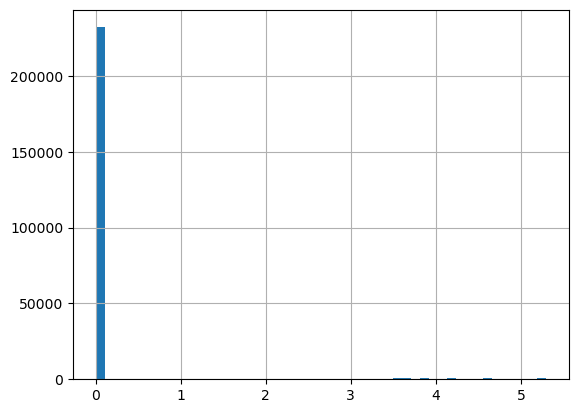

In [34]:
transformed_ihs_df['uk066011_ntot_noout_ihs'].hist(bins=50)

In [35]:
transformed_ihs_df.drop(columns=['uk066011_ntot_noout_ihs'], inplace=True)
transformed_ihs_df.shape

(239023, 29)

Join transformed variables with the rest

In [36]:
df_ntot_cl10_crrd_ihs = df_ntot_cl10_crrd.drop(columns=skew_df.index.to_list())
df_ntot_cl10_crrd_ihs.shape

(239023, 147)

In [37]:
df_ntot_cl10_crrd_ihs = df_ntot_cl10_crrd_ihs.join(transformed_ihs_df, how="inner")
df_ntot_cl10_crrd_ihs.shape

(239023, 176)

## Min-max normalisation

In [38]:
df_ntot_cl10_crrd_ihs_minmax = get_normd_min_max(df_ntot_cl10_crrd_ihs)
df_ntot_cl10_crrd_ihs_minmax.shape

(239023, 176)

In [39]:
df_ntot_cl10_crrd_ihs_minmax.head()

,uk001002_ntot_clipd_minmax,uk002002_ntot_noout_minmax,uk002003_ntot_noout_minmax,uk002004_ntot_clipd_minmax,uk002005_ntot_noout_minmax,uk002006_ntot_clipd_minmax,uk003002_ntot_noout_minmax,uk003003_ntot_noout_minmax,uk003005_ntot_noout_minmax,uk003006_ntot_noout_minmax,...,uk046007_ntot_clipd_ihs_minmax,uk046008_ntot_clipd_ihs_minmax,uk046009_ntot_clipd_ihs_minmax,uk046010_ntot_clipd_ihs_minmax,uk054009_ntot_clipd_ihs_minmax,uk061006_ntot_clipd_ihs_minmax,uk062010_ntot_clipd_ihs_minmax,uk066008_ntot_clipd_ihs_minmax,uk066012_ntot_clipd_ihs_minmax,uk066016_ntot_noout_ihs_minmax
OA,,,,,,,,,,,,,,,,,,,,,
E00000001,1.0,0.209183,0.640868,0.243536,0.169345,0.103164,0.366797,0.470588,0.601493,0.631579,...,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.229715,0.000000,0.0,0.522534
E00000003,1.0,0.309635,0.645161,0.020326,0.081774,0.086102,0.251195,0.407407,0.656334,0.680556,...,0.0,0.0,0.000000,1.000000,0.317584,0.000000,0.631733,0.112303,0.0,0.721809
E00000005,1.0,0.406816,0.426705,0.166442,0.186006,0.123386,0.418511,0.346154,0.550035,0.685714,...,0.0,0.0,0.540969,1.000000,0.000000,0.387720,0.450933,0.218938,0.0,0.531674
E00000007,1.0,0.714259,0.224682,0.063464,0.056738,0.067209,0.436292,0.081081,0.493789,0.744186,...,0.0,0.0,0.000000,0.746280,0.000000,0.270946,0.581465,0.000000,0.0,0.798493
E00000010,1.0,0.774129,0.182636,0.025794,0.092241,0.010926,0.760563,0.177083,0.193226,0.884615,...,0.0,0.0,0.000000,0.744087,0.000000,0.000000,0.392793,0.144368,1.0,0.691696


## Check for small quantile range

In [40]:
small_range_dict = get_small_range_cols(
    df_ntot_cl10_crrd_ihs_minmax, df_ntot_cl10_crrd_ihs_minmax.columns, 
    quant_bot=20, quant_top=80, threshold=0.05)
small_range_df = pd.DataFrame(small_range_dict)

small_range_df['column_orig'] = small_range_df['column_name'].str.split('_').str[0]
small_range_df = small_range_df.merge(vars_info, left_on='column_orig', right_on='Variable_ID', how='left').rename(columns={'Variable_Name': 'column_info'}).drop(columns=['Variable_ID', 'column_orig'])

small_range_df

,column_name,quant_bot,quant_top,range,column_info
0,uk001002_ntot_clipd_minmax,1.0,1.0,0.0,Residence type: Lives in a household
1,uk044008_ntot_clipd_ihs_minmax,0.0,0.0,0.0,Accommodation type: A caravan or other mobile ...
2,uk046007_ntot_clipd_ihs_minmax,0.0,0.0,0.0,Type of central heating in household: Wood only
3,uk046008_ntot_clipd_ihs_minmax,0.0,0.0,0.0,Type of central heating in household: Solid fu...
4,uk054009_ntot_clipd_ihs_minmax,0.0,0.0,0.0,Tenure of household: Lives rent free
5,uk066012_ntot_clipd_ihs_minmax,0.0,0.0,0.0,Economic activity status: Economically active ...


In [41]:
small_range_drop = small_range_df['column_name'].values.tolist()
small_range_drop.remove('uk001002_ntot_clipd_minmax')  # Keep this one for now
small_range_drop

['uk044008_ntot_clipd_ihs_minmax',
 'uk046007_ntot_clipd_ihs_minmax',
 'uk046008_ntot_clipd_ihs_minmax',
 'uk054009_ntot_clipd_ihs_minmax',
 'uk066012_ntot_clipd_ihs_minmax']

In [42]:
df_ntot_cl10_crrd_ihs_minmax_smrg = df_ntot_cl10_crrd_ihs_minmax.drop(columns=small_range_drop)
df_ntot_cl10_crrd_ihs_minmax_smrg.shape

(239023, 171)

In [43]:
df_ntot_cl10_crrd_ihs_minmax_smrg.head()

,uk001002_ntot_clipd_minmax,uk002002_ntot_noout_minmax,uk002003_ntot_noout_minmax,uk002004_ntot_clipd_minmax,uk002005_ntot_noout_minmax,uk002006_ntot_clipd_minmax,uk003002_ntot_noout_minmax,uk003003_ntot_noout_minmax,uk003005_ntot_noout_minmax,uk003006_ntot_noout_minmax,...,uk030005_ntot_clipd_ihs_minmax,uk030006_ntot_clipd_ihs_minmax,uk046004_ntot_clipd_ihs_minmax,uk046005_ntot_clipd_ihs_minmax,uk046009_ntot_clipd_ihs_minmax,uk046010_ntot_clipd_ihs_minmax,uk061006_ntot_clipd_ihs_minmax,uk062010_ntot_clipd_ihs_minmax,uk066008_ntot_clipd_ihs_minmax,uk066016_ntot_noout_ihs_minmax
OA,,,,,,,,,,,,,,,,,,,,,
E00000001,1.0,0.209183,0.640868,0.243536,0.169345,0.103164,0.366797,0.470588,0.601493,0.631579,...,0.285029,0.000000,0.310800,0.888200,0.000000,1.000000,0.000000,0.229715,0.000000,0.522534
E00000003,1.0,0.309635,0.645161,0.020326,0.081774,0.086102,0.251195,0.407407,0.656334,0.680556,...,0.345944,0.456294,0.000000,0.856471,0.000000,1.000000,0.000000,0.631733,0.112303,0.721809
E00000005,1.0,0.406816,0.426705,0.166442,0.186006,0.123386,0.418511,0.346154,0.550035,0.685714,...,0.175098,0.580362,0.000000,0.764779,0.540969,1.000000,0.387720,0.450933,0.218938,0.531674
E00000007,1.0,0.714259,0.224682,0.063464,0.056738,0.067209,0.436292,0.081081,0.493789,0.744186,...,0.378986,0.514418,0.542345,0.847968,0.000000,0.746280,0.270946,0.581465,0.000000,0.798493
E00000010,1.0,0.774129,0.182636,0.025794,0.092241,0.010926,0.760563,0.177083,0.193226,0.884615,...,0.337539,0.340955,0.418264,0.670164,0.000000,0.744087,0.000000,0.392793,0.144368,0.691696


## Save dataset

In [44]:
df_ntot_cl10_crrd_ihs_minmax_smrg.to_parquet('data/processed/28714514_2021UKCensus_processed_20251009001.parquet', index=True)
df_ntot_cl10_crrd_ihs_minmax_smrg.to_csv(    'data/processed/28714514_2021UKCensus_processed_20251009001.csv',     index=True)